In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/test.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/17f6c7072f61.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0243404e8a00.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0083ee8054ee.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0ac436400db4.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/0d0a21fd354f.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/02da652c74b8.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/15e96e848b46.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/059bc89df7f4.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/04d029cfb612.png
/kaggle/input/datasets/mariaherrerot/aptos2019/val_ima

In [3]:
import os

os.listdir("/kaggle/input")

['datasets']

In [4]:
import os

os.listdir("/kaggle/input/datasets")

['mariaherrerot']

In [5]:
os.listdir("/kaggle/input/datasets/mariaherrerot")

['aptos2019']

In [6]:
os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019")

['val_images',
 'train_images',
 'valid.csv',
 'test.csv',
 'train_1.csv',
 'test_images']

In [7]:
import pandas as pd 
import numpy as np 
DATASET_PATH = "/kaggle/input/datasets/mariaherrerot/aptos2019"

train_df = pd.read_csv(f"{DATASET_PATH}/train_1.csv")
valid_df = pd.read_csv(f"{DATASET_PATH}/valid.csv")
test_df = pd.read_csv(f"{DATASET_PATH}/test.csv")

print("TRAIN :", train_df.shape)
print("VALID :", valid_df.shape)
print("TEST  :", test_df.shape)

print("\nTrain columns:")
print(train_df.columns)

print("\nValid columns:")
print(valid_df.columns)

print("\nTrain sample:")
display(train_df.head())

print("\nValid sample:")
display(valid_df.head())

TRAIN : (2930, 2)
VALID : (366, 2)
TEST  : (366, 2)

Train columns:
Index(['id_code', 'diagnosis'], dtype='object')

Valid columns:
Index(['id_code', 'diagnosis'], dtype='object')

Train sample:


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0



Valid sample:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [8]:
DATASET_PATH = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_IMG_PATH = f"{DATASET_PATH}/train_images"
VALID_IMG_PATH = f"{DATASET_PATH}/val_images"
TEST_IMG_PATH = f"{DATASET_PATH}/test_images"

In [9]:
print("Train images:", len(os.listdir(TRAIN_IMG_PATH)))
print("Validation images:", len(os.listdir(VALID_IMG_PATH)))
print("Test images:", len(os.listdir(TEST_IMG_PATH)))

Train images: 1
Validation images: 1
Test images: 1


In [10]:
print("TRAIN:")
print(os.listdir(TRAIN_IMG_PATH))

print("\nVALID:")
print(os.listdir(VALID_IMG_PATH))

print("\nTEST:")
print(os.listdir(TEST_IMG_PATH))

TRAIN:
['train_images']

VALID:
['val_images']

TEST:
['test_images']


In [11]:
TRAIN_IMG_PATH = f"{DATASET_PATH}/train_images/train_images"
VALID_IMG_PATH = f"{DATASET_PATH}/val_images/val_images"
TEST_IMG_PATH = f"{DATASET_PATH}/test_images/test_images"

In [12]:
print("Train images:", len(os.listdir(TRAIN_IMG_PATH)))
print("Validation images:", len(os.listdir(VALID_IMG_PATH)))
print("Test images:", len(os.listdir(TEST_IMG_PATH)))

Train images: 2930
Validation images: 366
Test images: 366


In [13]:

print(os.listdir(TRAIN_IMG_PATH)[:10])

['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']


In [14]:
from PIL import Image
image_id = train_df.iloc[0]["id_code"]

image_path = os.path.join(
    TRAIN_IMG_PATH,
    image_id + ".png"
)

img = Image.open(image_path)

print("Image ID:", image_id)
print("Diagnosis:", train_df.iloc[0]["diagnosis"])
print("Image size:", img.size)
print("Image mode:", img.mode)

Image ID: 1ae8c165fd53
Diagnosis: 2
Image size: (3216, 2136)
Image mode: RGB


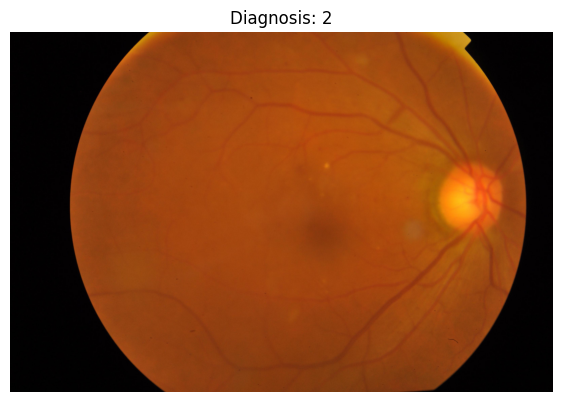

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title(f"Diagnosis: {train_df.iloc[0]['diagnosis']}")

plt.show()

In [16]:
sizes = []

for image_id in train_df["id_code"]:
    image_path = os.path.join(
        TRAIN_IMG_PATH,
        image_id + ".png"
    )

    with Image.open(image_path) as img:
        sizes.append(img.size)

print("Total images:", len(sizes))
print("Unique image sizes:", len(set(sizes)))

Total images: 2930
Unique image sizes: 17


In [17]:
from collections import Counter

Counter(sizes).most_common(10)

[((1050, 1050), 782),
 ((2416, 1736), 512),
 ((2588, 1958), 415),
 ((3216, 2136), 333),
 ((2048, 1536), 280),
 ((819, 614), 232),
 ((3388, 2588), 113),
 ((1504, 1000), 72),
 ((1844, 1226), 47),
 ((4288, 2848), 38)]

In [18]:
aspect_ratios = [
    width / height
    for width, height in sizes
]

print("Minimum aspect ratio:", min(aspect_ratios))
print("Maximum aspect ratio:", max(aspect_ratios))

Minimum aspect ratio: 1.0
Maximum aspect ratio: 1.5056179775280898


In [19]:
labels = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

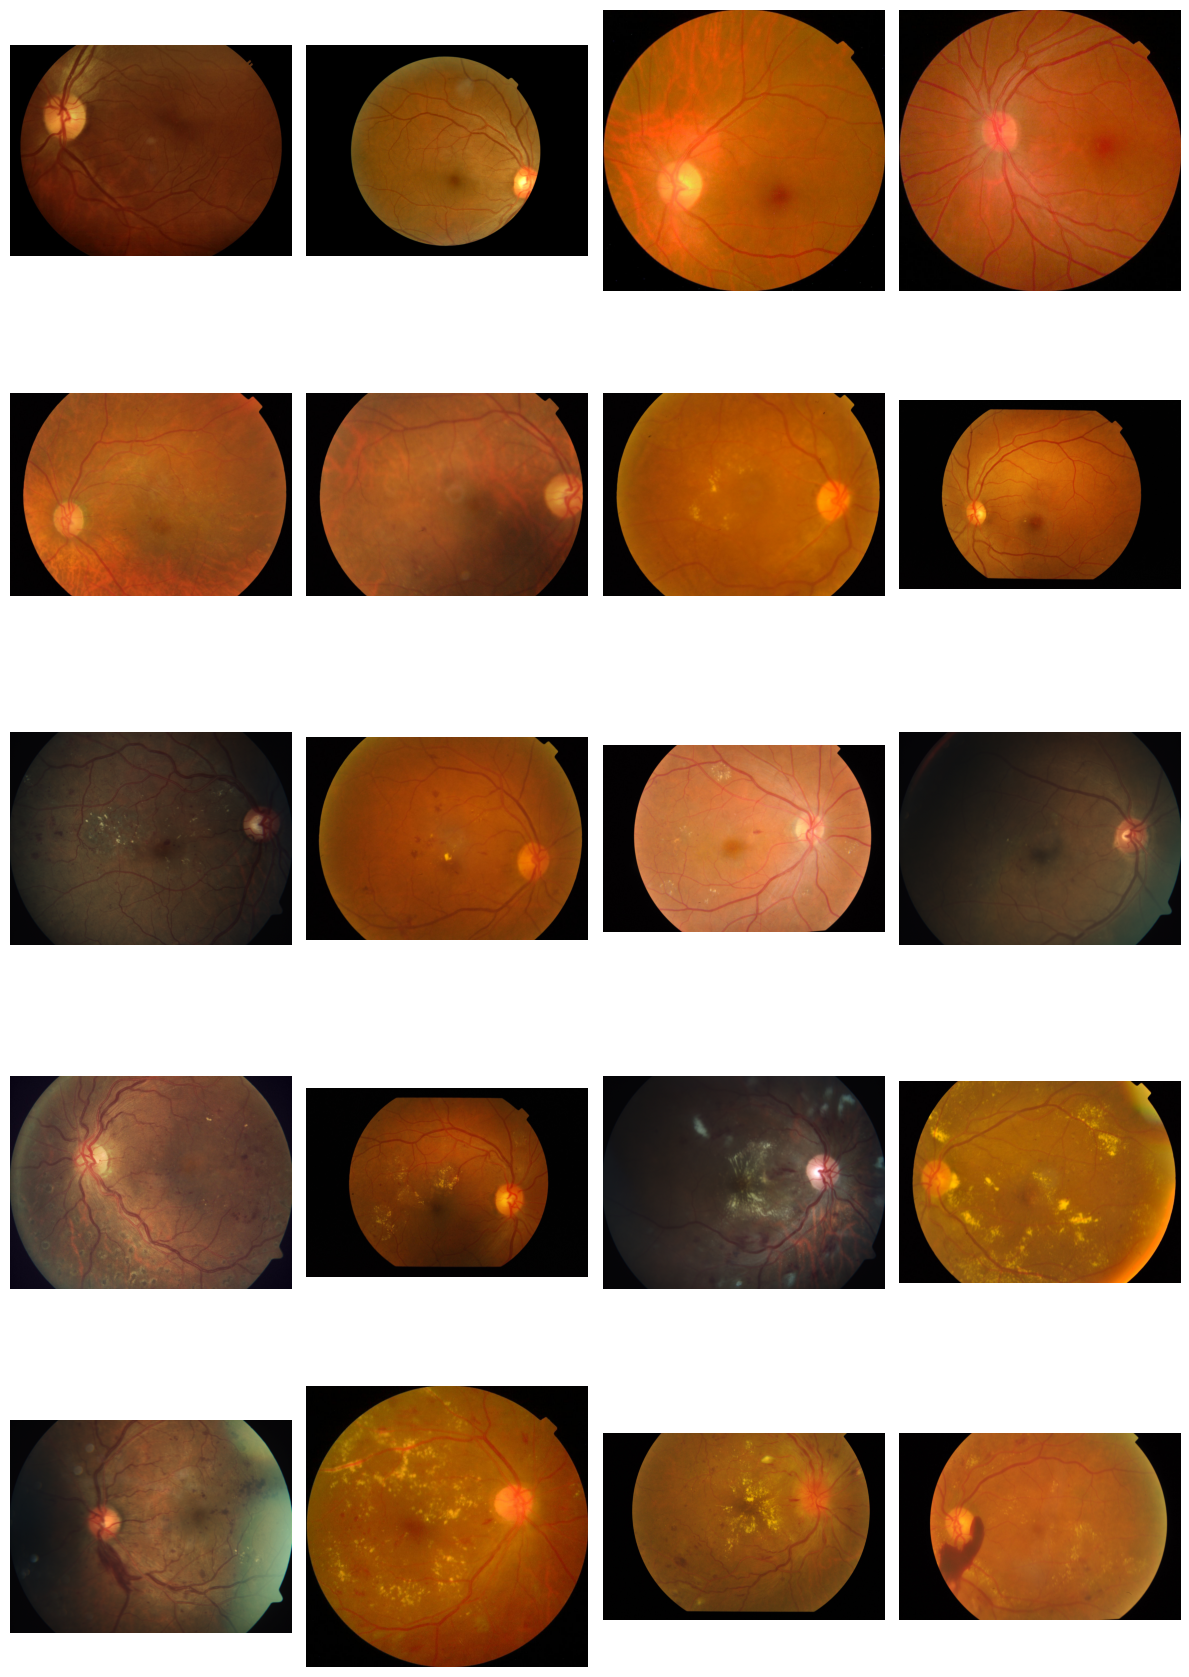

In [20]:
fig, axes = plt.subplots(5, 4, figsize=(12, 18))

for diagnosis in range(5):

    samples = train_df[
        train_df["diagnosis"] == diagnosis
    ].sample(4, random_state=42)

    for j, (_, row) in enumerate(samples.iterrows()):

        image_path = os.path.join(
            TRAIN_IMG_PATH,
            row["id_code"] + ".png"
        )

        img = Image.open(image_path)

        axes[diagnosis, j].imshow(img)
        axes[diagnosis, j].axis("off")

        if j == 0:
            axes[diagnosis, j].set_ylabel(
                labels[diagnosis],
                fontsize=12
            )

plt.tight_layout()
plt.show()

In [27]:
def get_image_stats(image_path):
    
    img = np.array(Image.open(image_path).convert("RGB"))
    
    # Convert RGB to grayscale
    gray = np.mean(img, axis=2)
    
    mean_brightness = gray.mean()
    std_brightness = gray.std()
    
    # Percentage of pixels that are almost black
    black_ratio = np.mean(gray < 10)
    
    return mean_brightness, std_brightness, black_ratio

In [ ]:
# stats = []

## for image_id in train_df["id_code"]:
    
  ##  image_path = os.path.join(
  /

# Image EDA

Before applying any image preprocessing or cleaning techniques, we performed Exploratory Data Analysis (EDA) on the retinal fundus images.

The objective of image EDA is to understand the characteristics and quality of the dataset and identify potential preprocessing requirements.

## 1. Image Dataset Overview

The dataset contains:

- **2,930 training images**
- **366 validation images**
- **366 test images**
- **5 diabetic retinopathy classes**
- Images are stored in **RGB format**

The training images have different resolutions, so image dimensions are not consistent across the dataset.

## 2. Image Dimensions

The training dataset contains **17 unique image resolutions**.

Some of the most common resolutions are:

| Image Resolution | Number of Images |
|---|---:|
| 1050 × 1050 | 782 |
| 2416 × 1736 | 512 |
| 2588 × 1958 | 415 |
| 3216 × 2136 | 333 |
| 2048 × 1536 | 280 |
| 819 × 614 | 232 |

This variation indicates that image dimensions need to be standardized before training the deep learning model.

## 3. Aspect Ratio Analysis

The aspect ratio was calculated as:

$$
\text{Aspect Ratio} = \frac{\text{Width}}{\text{Height}}
$$

The observed aspect ratios range from:

- **Minimum:** 1.0
- **Maximum:** approximately 1.506

Therefore, preprocessing should avoid unnecessarily distorting the retinal images when resizing them.

## 4. Visual Image Analysis

Images from all five diabetic retinopathy classes were randomly sampled and visualized.

The visual inspection showed:

- Significant variation in image brightness.
- Different amounts of black background surrounding the retinal field.
- Variation in image framing and retinal field size.
- Some variation in illumination and image quality.
- Retinal structures remain visible despite these variations.

## 5. Brightness Analysis

Mean pixel intensity was calculated for the sampled training images to understand the brightness distribution.

The histogram showed considerable variation in brightness, with most images concentrated in a moderate brightness range.

Some images were considerably darker or brighter than the majority.

However, mean brightness can be affected by the amount of black background present in an image. Therefore, brightness alone should not be used to identify poor-quality images.

## 6. Black Background Analysis

The proportion of nearly black pixels was also calculated.

The analysis showed that many images contain a considerable amount of black background outside the retinal field.

Images with a high black-pixel ratio were visually inspected and found to contain valid retinal information. Therefore, these images should **not be removed as corrupted or low-quality samples**.

Instead, the unnecessary background can potentially be removed during preprocessing.

## 7. Key Findings from Image EDA

Based on the analysis, the following preprocessing requirements were identified:

1. **Standardize image dimensions** because images have different resolutions.
2. **Preserve aspect ratio** to avoid geometric distortion.
3. **Reduce unnecessary black background** surrounding the retinal field.
4. **Investigate illumination/contrast normalization** because brightness varies across images.
5. **Avoid removing images solely based on black-pixel ratio**, since high black ratios can simply indicate larger background regions.

## Conclusion

Image EDA indicates that the APTOS 2019 dataset contains substantial variation in image resolution, framing, background area, and illumination.

Therefore, an image preprocessing pipeline will be developed to standardize the input images while preserving clinically relevant retinal information.

The next step is to design and test the **image cleaning and preprocessing pipeline** on representative samples before applying it to the complete dataset.

In [21]:
import cv2

In [22]:
image_id = train_df.iloc[0]["id_code"]

image_path = os.path.join(
    TRAIN_IMG_PATH,
    image_id + ".png"
)

img = cv2.imread(image_path)

print("Original shape:", img.shape)

Original shape: (2136, 3216, 3)


In [23]:
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)
print(gray)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


In [24]:
_, thresh = cv2.threshold(
    gray,
    15,
    255,
    cv2.THRESH_BINARY
)

In [25]:
coords = cv2.findNonZero(thresh)

In [26]:
x, y, w, h = cv2.boundingRect(coords)

In [27]:
cropped = img[
    y:y+h,
    x:x+w
]

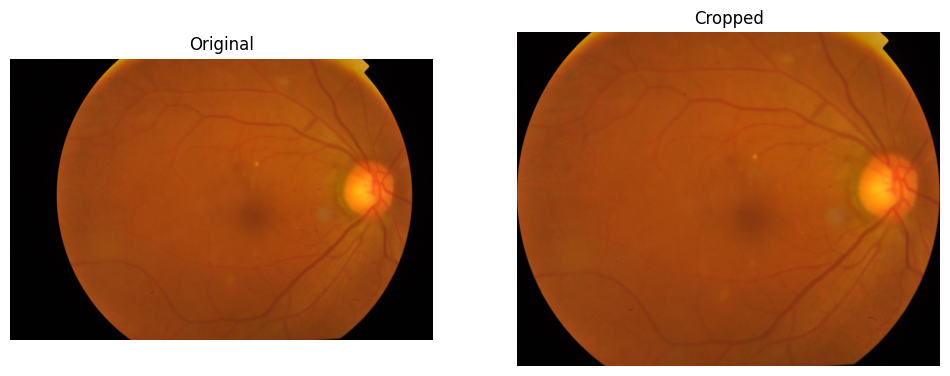

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
)

plt.title("Cropped")
plt.axis("off")

plt.show()

In [29]:
def crop_black_background(image_path, threshold=15):
    
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    _, thresh = cv2.threshold(
        gray,
        threshold,
        255,
        cv2.THRESH_BINARY
    )

    coords = cv2.findNonZero(thresh)

    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)

    cropped = img[
        y:y+h,
        x:x+w
    ]

    return cropped

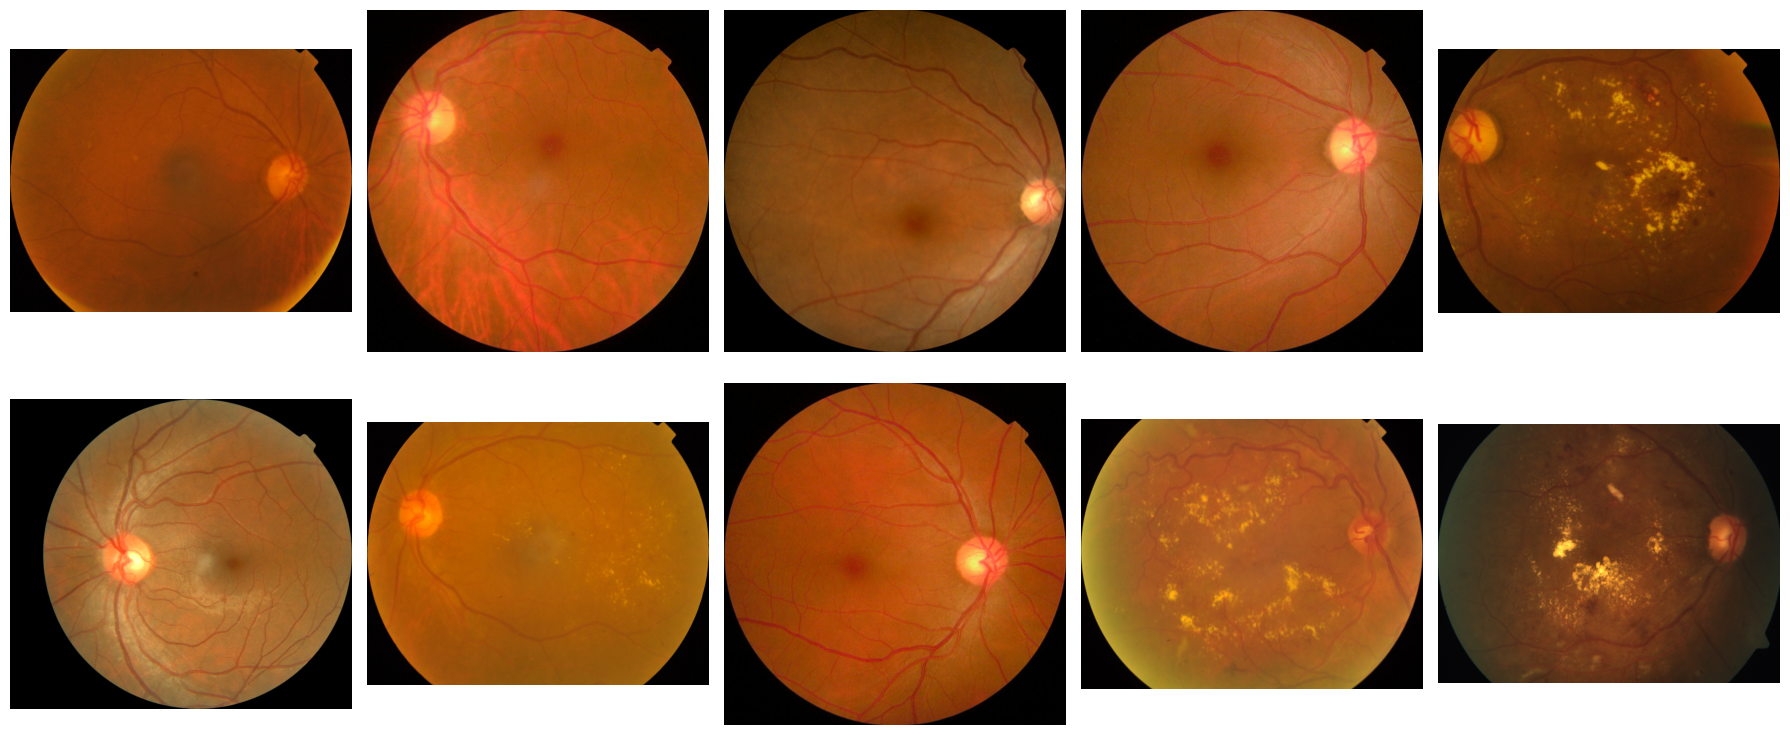

In [30]:
sample_ids = train_df.sample(
    10,
    random_state=42
)["id_code"]

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

for ax, image_id in zip(
    axes.ravel(),
    sample_ids
):

    image_path = os.path.join(
        TRAIN_IMG_PATH,
        image_id + ".png"
    )

    cropped = crop_black_background(
        image_path
    )

    cropped_rgb = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(cropped_rgb)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
def resize_with_padding(image, target_size=224):

    h, w = image.shape[:2]

    scale = min(
        target_size / w,
        target_size / h
    )

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        image,
        (new_w, new_h)
    )

    canvas = np.zeros(
        (target_size, target_size, 3),
        dtype=np.uint8
    )

    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas

In [32]:
processed = resize_with_padding(
    cropped,
    target_size=224
)

print("Original cropped:", cropped.shape)
print("Processed:", processed.shape)

Original cropped: (1958, 2588, 3)
Processed: (224, 224, 3)


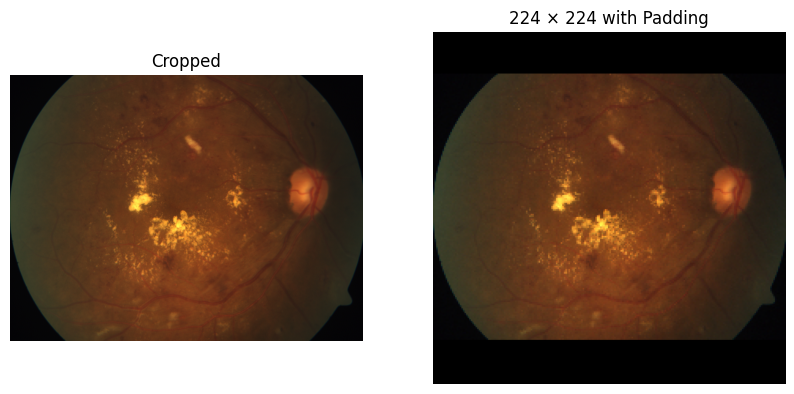

In [33]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
)
plt.title("Cropped")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
)
plt.title("224 × 224 with Padding")
plt.axis("off")

plt.show()

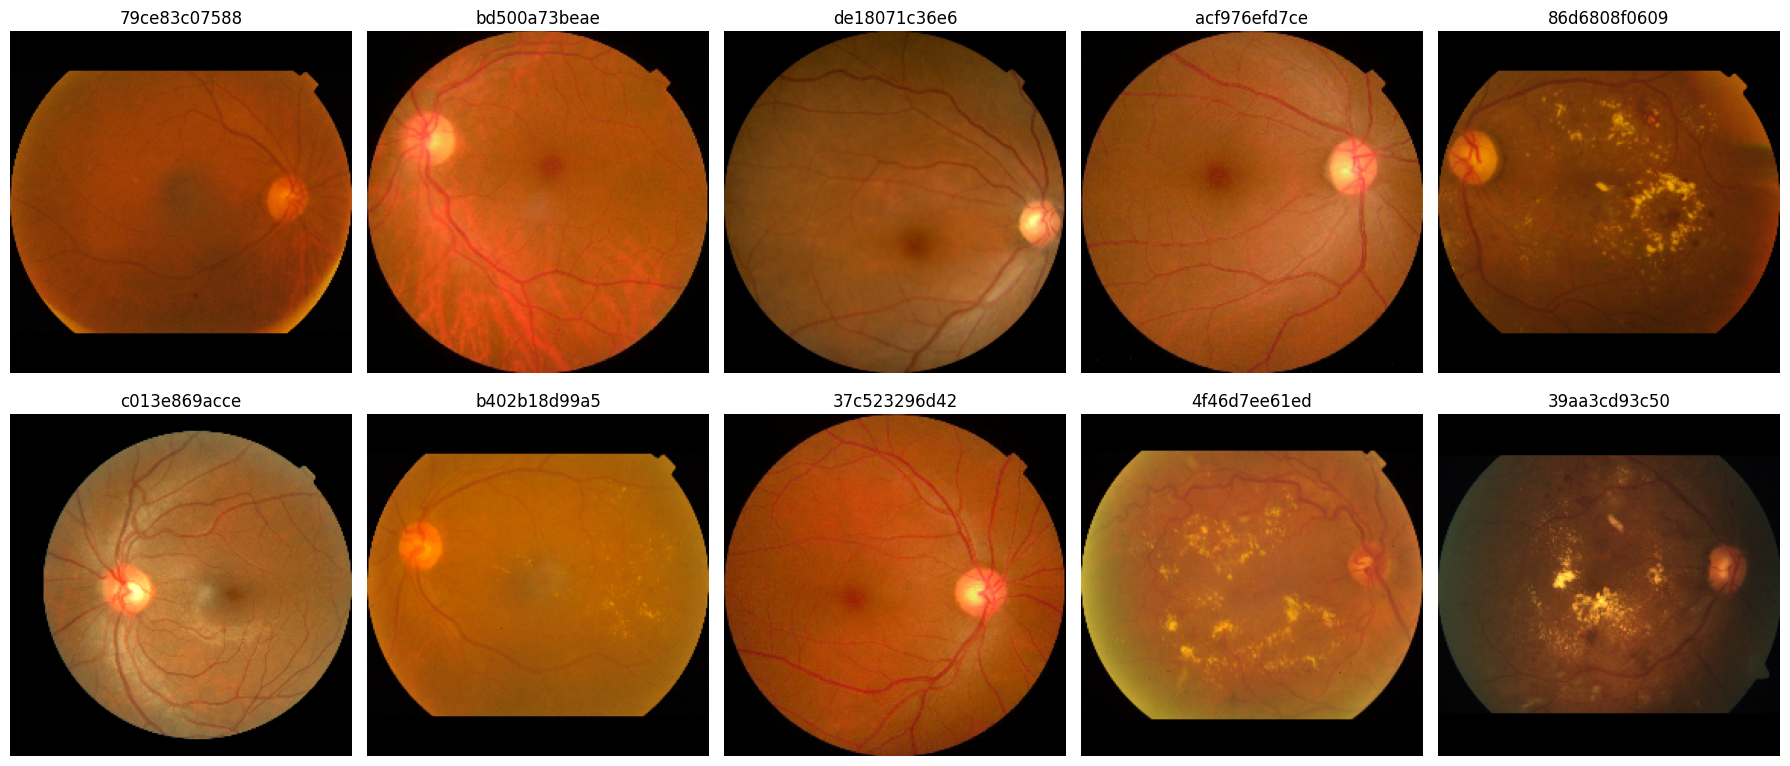

In [34]:
sample_ids = train_df.sample(
    10,
    random_state=42
)["id_code"]

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

for ax, image_id in zip(axes.ravel(), sample_ids):

    image_path = os.path.join(
        TRAIN_IMG_PATH,
        image_id + ".png"
    )

    cropped = crop_black_background(image_path)

    processed = resize_with_padding(
        cropped,
        target_size=224
    )

    processed_rgb = cv2.cvtColor(
        processed,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(processed_rgb)
    ax.set_title(image_id)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
def preprocess_image(image_path, target_size=224):

    # 1. Read image
    img = cv2.imread(image_path)

    # 2. Convert to grayscale
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # 3. Create binary mask
    _, thresh = cv2.threshold(
        gray,
        15,
        255,
        cv2.THRESH_BINARY
    )

    # 4. Find non-black region
    coords = cv2.findNonZero(thresh)

    # 5. If no region is found, return original image
    if coords is None:
        cropped = img
    else:
        # 6. Find bounding box
        x, y, w, h = cv2.boundingRect(coords)

        # 7. Crop the image
        cropped = img[
            y:y+h,
            x:x+w
        ]

    # 8. Get cropped dimensions
    h, w = cropped.shape[:2]

    # 9. Calculate scale while preserving aspect ratio
    scale = min(
        target_size / w,
        target_size / h
    )

    # 10. Calculate new dimensions
    new_w = int(w * scale)
    new_h = int(h * scale)

    # 11. Resize
    resized = cv2.resize(
        cropped,
        (new_w, new_h)
    )

    # 12. Create black canvas
    canvas = np.zeros(
        (target_size, target_size, 3),
        dtype=np.uint8
    )

    # 13. Calculate padding
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    # 14. Place resized image on canvas
    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    # 15. Return final image
    return canvas

In [36]:
processed = preprocess_image(
    image_path
)

print("Processed shape:", processed.shape)

Processed shape: (224, 224, 3)


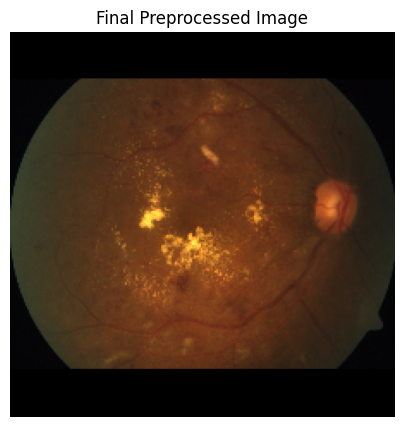

In [37]:
plt.figure(figsize=(5, 5))

plt.imshow(
    cv2.cvtColor(
        processed,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Final Preprocessed Image")
plt.axis("off")

plt.show()

In [38]:
normalized = processed.astype(np.float32) / 255.0

print("Before normalization:")
print("Min:", processed.min())
print("Max:", processed.max())

print("\nAfter normalization:")
print("Min:", normalized.min())
print("Max:", normalized.max())
print("Data type:", normalized.dtype)

Before normalization:
Min: 0
Max: 255

After normalization:
Min: 0.0
Max: 1.0
Data type: float32


# Image Preprocessing

Based on the image EDA, the following preprocessing pipeline was developed:

1. **Background Cropping**  
   Unnecessary black regions surrounding the retinal field are reduced using threshold-based bounding-box detection.

2. **Aspect-Ratio-Preserving Resize**  
   Images are resized while maintaining their original aspect ratio to avoid geometric distortion.

3. **Padding**  
   The resized image is placed on a square canvas with black padding to obtain a fixed input size of `224 × 224`.

4. **Normalization**  
   Pixel values are converted from the `0–255` range to the `0–1` range using:

   $$x_{normalized} = \frac{x}{255}$$

This preprocessing ensures that images have a consistent spatial size and numerical representation before being passed to the deep learning model.

In [39]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [40]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [41]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
])

I0000 00:00:1788149740.591372      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788149740.594130      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [42]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [43]:
sample_rgb = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

sample_rgb = sample_rgb.astype(
    np.float32
) / 255.0

print("Shape:", sample_rgb.shape)
print("Min:", sample_rgb.min())
print("Max:", sample_rgb.max())

Shape: (224, 224, 3)
Min: 0.0
Max: 1.0


In [44]:
sample_rgb = tf.expand_dims(
    sample_rgb,
    axis=0
)

print(sample_rgb.shape)

(1, 224, 224, 3)


In [45]:
augmented = data_augmentation(
    sample_rgb,
    training=True
)

print(augmented.shape)

(1, 224, 224, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0262986].


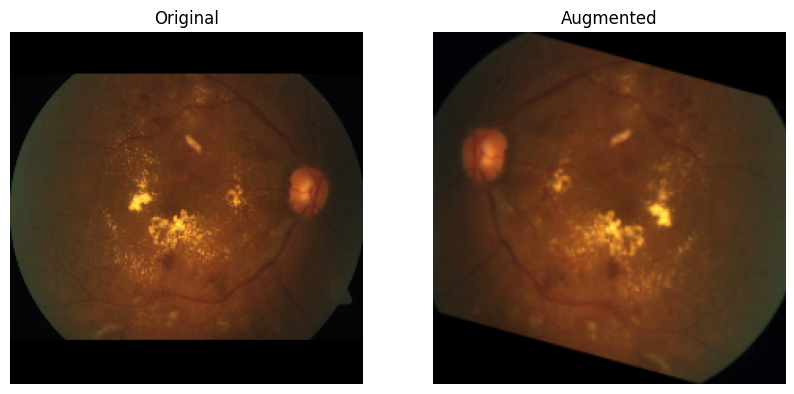

In [46]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(sample_rgb[0])
plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(augmented[0])
plt.title("Augmented")
plt.axis("off")

plt.show()

In [47]:
augmented = data_augmentation(
    sample_rgb,
    training=True
)

print(augmented.shape)

(1, 224, 224, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0302223].


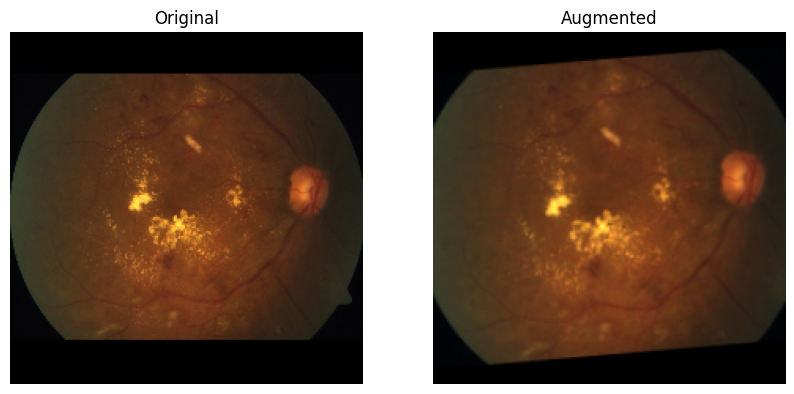

In [48]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(sample_rgb[0])
plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(augmented[0])
plt.title("Augmented")
plt.axis("off")

plt.show()

In [49]:
augmented = data_augmentation(
    sample_rgb,
    training=True
)

print(augmented.shape)

(1, 224, 224, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.035628].


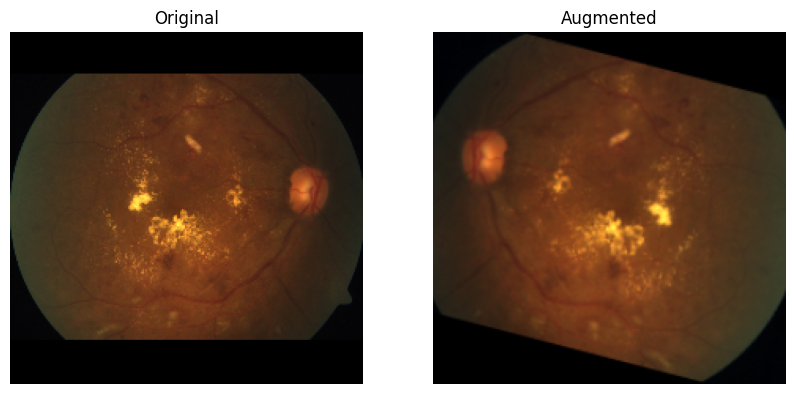

In [50]:

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(sample_rgb[0])
plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(augmented[0])
plt.title("Augmented")
plt.axis("off")

plt.show()

In [51]:
image_id = train_df.iloc[0]["id_code"]
label = train_df.iloc[0]["diagnosis"]

image_path = os.path.join(
    TRAIN_IMG_PATH,
    image_id + ".png"
)

processed = preprocess_image(
    image_path,
    target_size=224
)

processed_rgb = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

image = processed_rgb.astype(
    np.float32
) / 255.0

print("Image shape:", image.shape)
print("Label:", label)
print("Min:", image.min())
print("Max:", image.max())

Image shape: (224, 224, 3)
Label: 2
Min: 0.0
Max: 1.0


In [52]:
def load_and_preprocess(image_id, label, image_path):

    image_id = image_id.numpy()

    if isinstance(image_id, bytes):
        image_id = image_id.decode("utf-8")
    else:
        image_id = image_id.item().decode("utf-8")

    full_path = os.path.join(
        image_path,
        image_id + ".png"
    )

    image = preprocess_image(
        full_path,
        target_size=224
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # IMPORTANT: Keep 0–255
    image = image.astype(np.float32)

    return image, label

In [53]:
def tf_load_and_preprocess(
    image_id,
    label,
    image_path
):

    image, label = tf.py_function(
        func=lambda x, y: load_and_preprocess(
            x, y, image_path
        ),
        inp=[image_id, label],
        Tout=[tf.float32, tf.int64]
    )

    image.set_shape((224, 224, 3))
    label.set_shape(())

    return image, label

In [54]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["id_code"].values,
        train_df["diagnosis"].values
    )
)

train_dataset = train_dataset.map(
    lambda image_id, label: tf_load_and_preprocess(
        image_id,
        label,
        TRAIN_IMG_PATH
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(32)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [55]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("Image min:", images.numpy().min())
    print("Image max:", images.numpy().max())

    print("Labels:", labels.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image min: 0.0
Image max: 255.0
Labels: [2 1 4 0 0 2 3 0 0 2 1 2 4 1 2 0 1 0 2 4 2 2 2 2 0 3 0 0 0 0 0 0]


In [56]:
def augment_train(image, label):

    image = data_augmentation(
        image,
        training=True
    )

    return image, label

In [57]:
train_dataset = train_dataset.map(
    augment_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [58]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("Image min:", images.numpy().min())
    print("Image max:", images.numpy().max())

    print("Labels:", labels.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image min: 0.0
Image max: 255.0
Labels: [2 1 4 0 0 2 3 0 0 2 1 2 4 1 2 0 1 0 2 4 2 2 2 2 0 3 0 0 0 0 0 0]


In [59]:
valid_dataset = tf.data.Dataset.from_tensor_slices(
    (
        valid_df["id_code"].values,
        valid_df["diagnosis"].values
    )
)

valid_dataset = valid_dataset.map(
    lambda image_id, label: tf_load_and_preprocess(
        image_id,
        label,
        VALID_IMG_PATH
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

valid_dataset = valid_dataset.batch(32)

valid_dataset = valid_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [60]:
for images, labels in valid_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("Image min:", images.numpy().min())
    print("Image max:", images.numpy().max())

    print("Labels:", labels.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image min: 0.0
Image max: 255.0
Labels: [2 4 1 0 0 4 0 2 2 1 0 2 0 3 1 0 2 0 0 2 2 0 1 2 0 2 0 0 0 0 0 0]


In [61]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["id_code"].values,
        test_df["diagnosis"].values
    )
)

test_dataset = test_dataset.map(
    lambda image_id, label: tf_load_and_preprocess(
        image_id,
        label,
        TEST_IMG_PATH
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(32)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [62]:
for images, labels in test_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("Image min:", images.numpy().min())
    print("Image max:", images.numpy().max())

    print("Labels:", labels.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image min: 0.0
Image max: 255.0
Labels: [0 2 4 0 0 0 3 2 1 1 0 0 2 0 2 0 0 0 0 4 0 0 2 2 2 0 0 0 0 0 2 0]


# Data Preparation and Preprocessing

The APTOS 2019 dataset contains retinal fundus images along with their corresponding diabetic retinopathy severity labels.

Before training the deep learning model, the images were explored, cleaned, standardized, and converted into a format suitable for neural network training.

## 1. Dataset Structure

The dataset was divided into three subsets:

- **Training Set:** 2,930 images
- **Validation Set:** 366 images
- **Test Set:** 366 images

Each image is associated with a `diagnosis` label ranging from 0 to 4.

## 2. Class Distribution

The training dataset contains five diabetic retinopathy classes:

| Label | Class | Number of Images |
|------:|-------|-----------------:|
| 0 | No Diabetic Retinopathy | 1,434 |
| 1 | Mild | 300 |
| 2 | Moderate | 808 |
| 3 | Severe | 154 |
| 4 | Proliferative Diabetic Retinopathy | 234 |

The dataset is imbalanced, with Class 0 having the highest number of samples and Class 3 having the fewest.

This class imbalance will be considered during model training and evaluation.

## 3. Image Exploration

The training images were inspected to understand their:

- Dimensions
- Aspect ratios
- Color format
- Brightness
- Background regions
- Visual differences between diabetic retinopathy classes

The images were found to have different resolutions and aspect ratios.

### Image Dimensions

The dataset contains multiple image resolutions, for example:

- 1050 × 1050
- 2416 × 1736
- 2588 × 1958
- 3216 × 2136
- 2048 × 1536

The aspect ratios range approximately from 1.0 to 1.51.

Therefore, the images cannot be directly fed into a neural network without standardizing their dimensions.

## 4. Black Background Removal

Fundus images contain regions outside the circular retinal field that are mostly black.

These unnecessary background regions were detected and cropped to focus the model on the useful retinal area.

This reduces irrelevant information and allows the model to focus more on retinal structures.

## 5. Image Resizing and Padding

After cropping, images were resized while preserving their original aspect ratio.

The images were then padded to obtain a fixed size of:

**224 × 224 × 3**

Padding was used instead of simply stretching the image so that the retinal structures were not unnecessarily distorted.

## 6. Color Conversion

Images loaded using OpenCV are initially represented in **BGR** format.

Since most deep learning visualization and model pipelines expect **RGB**, the images were converted from:

BGR → RGB

This prevents incorrect color representation from being passed to the model.

## 7. Normalization

Pixel values originally range from:

**0 to 255**

They were normalized to:

**0 to 1**

using:

`pixel_value / 255.0`

This produces floating-point image tensors with `float32` data type.

Normalization helps provide a more suitable numerical range for neural network training.

## 8. Data Augmentation

Because the training dataset is relatively small, data augmentation was applied to the training images.

The following transformations were used:

- Random horizontal flipping
- Small random rotations
- Random zoom
- Random contrast adjustment

These transformations create realistic variations of training images and can improve the model's ability to generalize.

### Important

Data augmentation is applied **only to the training dataset**.

Validation and test images are not randomly augmented.

## 9. TensorFlow Data Pipeline

A `tf.data` pipeline was created to efficiently load and preprocess the images.

The pipeline performs:

Image ID + Label  
→ Image Loading  
→ Cropping  
→ Resizing + Padding  
→ BGR to RGB  
→ Normalization  
→ Batching  
→ Data Augmentation (Training Only)  
→ Prefetching

A batch size of **32** is used.

The final image tensor has the shape:

**(224, 224, 3)**

and a training batch has the shape:

**(32, 224, 224, 3)**

## 10. Final Data Preparation

The final datasets are:

### Training Dataset

- 2,930 images
- Preprocessing applied
- Normalization applied
- Data augmentation applied
- Batch size = 32
- Prefetching enabled

### Validation Dataset

- 366 images
- Preprocessing applied
- Normalization applied
- No random augmentation
- Batch size = 32
- Prefetching enabled

### Test Dataset

- 366 images
- Preprocessing applied
- Normalization applied
- No random augmentation
- Batch size = 32
- Prefetching enabled

The data preparation pipeline is now ready for model development and training.

In [63]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [64]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [65]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_aptos_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [66]:
class_weights = {
    0: 0.409,
    1: 1.953,
    2: 0.725,
    3: 3.805,
    4: 2.504
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(f"Class {class_id}: {weight:.3f}")

Class weights:
Class 0: 0.409
Class 1: 1.953
Class 2: 0.725
Class 3: 3.805
Class 4: 2.504


In [67]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20


2026-08-31 04:19:22.529938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:19:22.673701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:19:23.109541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:19:23.259846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:19:24.536201: E external/local_xla/xla/stream_

84/92 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4786 - loss: 1.4320

2026-08-31 04:22:20.845744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:22:20.983988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:22:21.302656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:22:21.443467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-31 04:22:22.208574: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 0.84974, saving model to /kaggle/working/best_aptos_model.keras

Epoch 1: finished saving model to /kaggle/working/best_aptos_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.5505 - loss: 1.3221 - val_accuracy: 0.6667 - val_loss: 0.8497 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6237 - loss: 1.1377
Epoch 2: val_loss improved from 0.84974 to 0.79267, saving model to /kaggle/working/best_aptos_model.keras

Epoch 2: finished saving model to /kaggle/working/best_aptos_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.6317 - loss: 1.1167 - val_accuracy: 0.6967 - val_loss: 0.7927 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6609 - loss: 1.0474
Epoch 3: val_loss improved from 0.79267 to 0.76592, saving model to /kaggle/working/best_aptos_model.keras

Epoch 3: finished saving model to /kaggle/working/best_aptos_model.keras
92/92 ━━━━━━━

In [68]:
import os

path = "/kaggle/working/best_aptos_model.keras"

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("Size:",
          round(os.path.getsize(path) / (1024**2), 2),
          "MB")

Exists: True
Size: 16.33 MB


In [69]:
import numpy as np

y_true = []
y_prob = []

for images, labels in test_dataset:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true)
y_prob = np.array(y_prob)

print("True labels:", y_true.shape)
print("Predictions:", y_prob.shape)

True labels: (366,)
Predictions: (366, 5)


In [70]:
y_pred = np.argmax(y_prob, axis=1)

print("Predicted distribution:")
print(np.unique(y_pred, return_counts=True))

print("\nTest Accuracy:")
print(np.mean(y_true == y_pred))

Predicted distribution:
(array([0, 1, 2, 3, 4]), array([195,  46,  83,  19,  23]))

Test Accuracy:
0.7622950819672131


In [71]:
y_val_true = []
y_val_prob = []

for images, labels in valid_dataset:
    probs = model.predict(images, verbose=0)

    y_val_true.extend(labels.numpy())
    y_val_prob.extend(probs)

y_val_true = np.array(y_val_true)
y_val_prob = np.array(y_val_prob)

print("Validation labels:", y_val_true.shape)
print("Validation probabilities:", y_val_prob.shape)

Validation labels: (366,)
Validation probabilities: (366, 5)


In [72]:
from sklearn.metrics import confusion_matrix

# Convert 5-class problem into Referable vs Non-
# Grade 0-1 = Non-Referable
# Grade 2-4 = Referable

y_val_binary = (y_val_true >= 2).astype(int)

# Probability that image is Referable (Grade 2, 3 or 4)
y_val_referable_prob = np.sum(y_val_prob[:, 2:5], axis=1)

results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_val_pred_binary = (
        y_val_referable_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_binary,
        y_val_pred_binary,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append([
        threshold,
        sensitivity * 100,
        specificity * 100
    ])

results = np.array(results)

# Find thresholds satisfying SIH requirements
valid = results[
    (results[:, 1] > 90) &
    (results[:, 2] > 85)
]

print("Thresholds satisfying SIH target:")

if len(valid) > 0:
    for row in valid:
        print(
            f"Threshold: {row[0]:.2f} | "
            f"Sensitivity: {row[1]:.2f}% | "
            f"Specificity: {row[2]:.2f}%"
        )
else:
    print("No threshold satisfies both targets.")

print("\nBest sensitivity while specificity >85%:")

spec_ok = results[results[:, 2] > 85]

if len(spec_ok) > 0:
    best = spec_ok[np.argmax(spec_ok[:, 1])]

    print(
        f"Threshold: {best[0]:.2f} | "
        f"Sensitivity: {best[1]:.2f}% | "
        f"Specificity: {best[2]:.2f}%"
    )

Thresholds satisfying SIH target:
Threshold: 0.33 | Sensitivity: 97.40% | Specificity: 85.38%
Threshold: 0.34 | Sensitivity: 97.40% | Specificity: 86.32%
Threshold: 0.35 | Sensitivity: 97.40% | Specificity: 86.79%
Threshold: 0.36 | Sensitivity: 97.40% | Specificity: 87.74%
Threshold: 0.37 | Sensitivity: 96.75% | Specificity: 88.21%
Threshold: 0.38 | Sensitivity: 95.45% | Specificity: 88.68%
Threshold: 0.39 | Sensitivity: 95.45% | Specificity: 88.68%
Threshold: 0.40 | Sensitivity: 95.45% | Specificity: 89.15%
Threshold: 0.41 | Sensitivity: 94.81% | Specificity: 89.62%
Threshold: 0.42 | Sensitivity: 93.51% | Specificity: 90.57%
Threshold: 0.43 | Sensitivity: 92.86% | Specificity: 90.57%
Threshold: 0.44 | Sensitivity: 92.86% | Specificity: 91.04%
Threshold: 0.45 | Sensitivity: 90.91% | Specificity: 91.51%
Threshold: 0.46 | Sensitivity: 90.91% | Specificity: 91.51%
Threshold: 0.47 | Sensitivity: 90.91% | Specificity: 91.51%
Threshold: 0.48 | Sensitivity: 90.26% | Specificity: 91.98%

Best 

In [73]:
from sklearn.metrics import confusion_matrix

# Frozen threshold selected using validation set
threshold = 0.42

# True binary labels
y_test_binary = (y_true >= 2).astype(int)

# Referable DR probability
y_test_referable_prob = np.sum(y_prob[:, 2:5], axis=1)

# Apply frozen threshold
y_test_binary_pred = (
    y_test_referable_prob >= threshold
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_binary,
    y_test_binary_pred,
    labels=[0, 1]
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Binary Confusion Matrix:")
print(confusion_matrix(
    y_test_binary,
    y_test_binary_pred,
    labels=[0, 1]
))

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

print("\nPercentage:")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")

Binary Confusion Matrix:
[[208  21]
 [  9 128]]

Sensitivity: 0.9343065693430657
Specificity: 0.9082969432314411

Percentage:
Sensitivity: 93.43%
Specificity: 90.83%


In [74]:
import json

config = {
    "model_file": "best_aptos_model.keras",
    "threshold": 0.42,
    "referable_classes": [2, 3, 4],
    "non_referable_classes": [0, 1],
    "test_accuracy": 0.7622950819672131,
    "sensitivity": 0.9343065693430657,
    "specificity": 0.9082969432314411,
    "best_epoch": 9,
    "best_val_loss": 0.68049
}

with open("/kaggle/working/aptos_model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Config saved successfully")

Config saved successfully


In [75]:
import os

for file in [
    "/kaggle/working/best_aptos_model.keras",
    "/kaggle/working/aptos_model_config.json"
]:
    print(
        os.path.basename(file),
        "→",
        os.path.exists(file),
        "→",
        round(os.path.getsize(file) / (1024**2), 2),
        "MB"
    )

best_aptos_model.keras → True → 16.33 MB
aptos_model_config.json → True → 0.0 MB
